In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy import stats
from scipy.signal import find_peaks
import pandas as pd

In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

In [2]:
datos = sio.loadmat('signals.mat')
def RMS(datos):
    x = np.asarray(datos)
    return np.sqrt(np.mean(x**2))

In [3]:
print(datos.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


In [4]:
duracion= len(datos["ECG_asRecording"].squeeze())/datos["Fs"]
print("Duración de la señal:", duracion, "segundos")
tiempo= np.arange(0, duracion, 1/datos["Fs"])
print("Tiempo de la señal:", tiempo)

Duración de la señal: [[30.]] segundos
Tiempo de la señal: [0.00000000e+00 9.76562500e-04 1.95312500e-03 ... 2.99970703e+01
 2.99980469e+01 2.99990234e+01]


C:\Users\Victoria Catalina\AppData\Local\Temp\ipykernel_19080\691882476.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tiempo= np.arange(0, duracion, 1/datos["Fs"])


In [5]:
np.linspace(0, duracion, len(datos["ECG_asRecording"].squeeze()))

array([[[0.00000000e+00]],

       [[9.76594290e-04]],

       [[1.95318858e-03]],

       ...,

       [[2.99980468e+01]],

       [[2.99990234e+01]],

       [[3.00000000e+01]]])

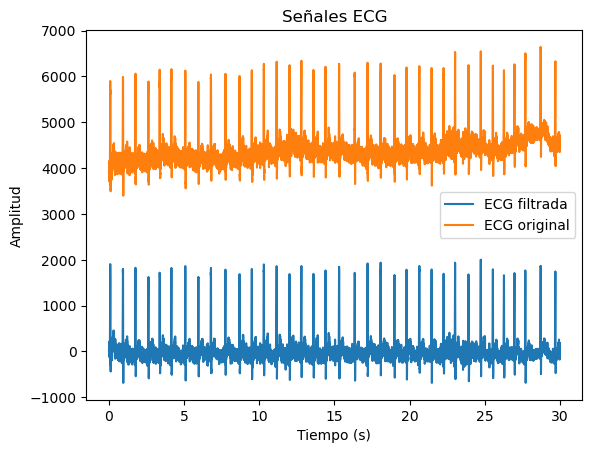

In [26]:
plt.plot(tiempo,datos["ECG_filtered"].squeeze(), label="ECG filtrada")
plt.plot(tiempo, datos["ECG_asRecording"].squeeze(), label="ECG original")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("Señales ECG")
plt.legend()
plt.show()

**Comente lo que observa, y describa cómo debe ser el comportamiento del filtro que se utilizó**

Promedio: 4117.387503835269
RMS: 4127.522368515574
Varianza: 83561.04585758828
Desviación estándar: 289.0692751877796


C:\Users\Victoria Catalina\AppData\Local\Temp\ipykernel_19080\2030629681.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t2=np.arange(0, 0.833, 1/datos["Fs"])


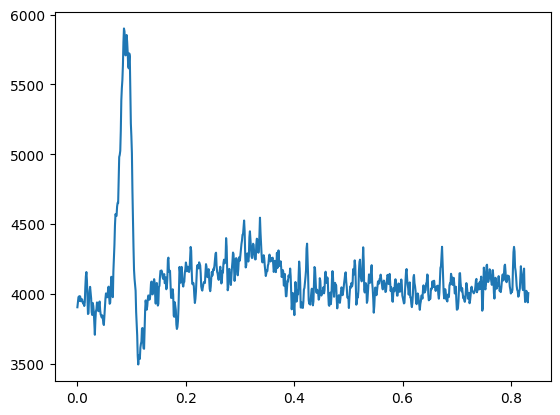

In [6]:
t2=np.arange(0, 0.833, 1/datos["Fs"])
plt.plot(tiempo[tiempo <= 0.833], datos["ECG_asRecording"].squeeze()[tiempo <= 0.833], label="ECG original")
ciclo=datos["ECG_asRecording"].squeeze()[tiempo <= 0.833]
promedio=np.mean(ciclo)
RMS_ciclo=RMS(ciclo)
varianza=np.var(ciclo)
desviacion=np.std(ciclo)
print('Promedio:', promedio)
print('RMS:', RMS_ciclo)
print('Varianza:', varianza)
print('Desviación estándar:', desviacion)

Promedio: 86.7684631038628
RMS: 319.2743328171337
Varianza: 94407.33340641946
Desviación estándar: 307.25776378542406


C:\Users\Victoria Catalina\AppData\Local\Temp\ipykernel_19080\2294712416.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t2=np.arange(0, 0.833, 1/datos["Fs"])


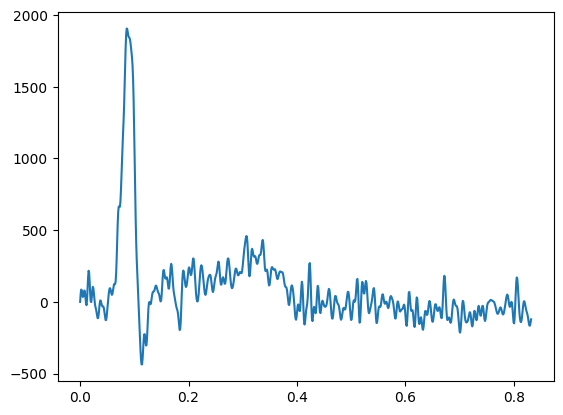

In [7]:
t2=np.arange(0, 0.833, 1/datos["Fs"])
plt.plot(tiempo[tiempo <= 0.833], datos["ECG_filtered"].squeeze()[tiempo <= 0.833], label="ECG filtrado")
ciclo_filtrada=datos["ECG_filtered"].squeeze()[tiempo <= 0.833]
promedio=np.mean(ciclo_filtrada)
RMS_ciclo=RMS(ciclo_filtrada)
varianza=np.var(ciclo_filtrada)
desviacion=np.std(ciclo_filtrada)
print('Promedio:', promedio)
print('RMS:', RMS_ciclo)
print('Varianza:', varianza)
print('Desviación estándar:', desviacion)

In [13]:
Fs = datos["Fs"].squeeze()

ecg_original = datos["ECG_asRecording"].squeeze()
ecg_filtrado = datos["ECG_filtered"].squeeze()

picos, _ = find_peaks(
    ecg_filtrado,
    distance=int(0.5 * Fs),
    prominence=np.std(ecg_filtrado)
)

ciclos = []

for i in range(1, 16):
    
    inicio = picos[i]
    fin = picos[i+1]
    
    ciclo = ecg_filtrado[inicio:fin]
    
    ciclos.append(ciclo)

print("Número de ciclos extraídos:", len(ciclos))

promedios = []
varianzas = []

for ciclo in ciclos:
    
    promedio = np.mean(ciclo)
    varianza = np.var(ciclo, ddof=1)
    
    promedios.append(promedio)
    varianzas.append(varianza)
tabla_ciclos = pd.DataFrame({
    "Ciclo": np.arange(1, 16),
    "Promedio": promedios,
    "Varianza": varianzas
})

tabla_ciclos

Número de ciclos extraídos: 15


,Ciclo,Promedio,Varianza
0,1,-1.462578,104913.314804
1,2,-10.433000,82544.311181
2,3,-20.975178,46900.649983
3,4,40.871105,114993.403360
4,5,-27.943734,58209.186534
5,6,0.430787,77794.789401
6,7,21.407853,100384.908165
7,8,-10.175290,71857.833914
8,9,8.812103,68552.098206
9,10,-8.906158,76179.947335


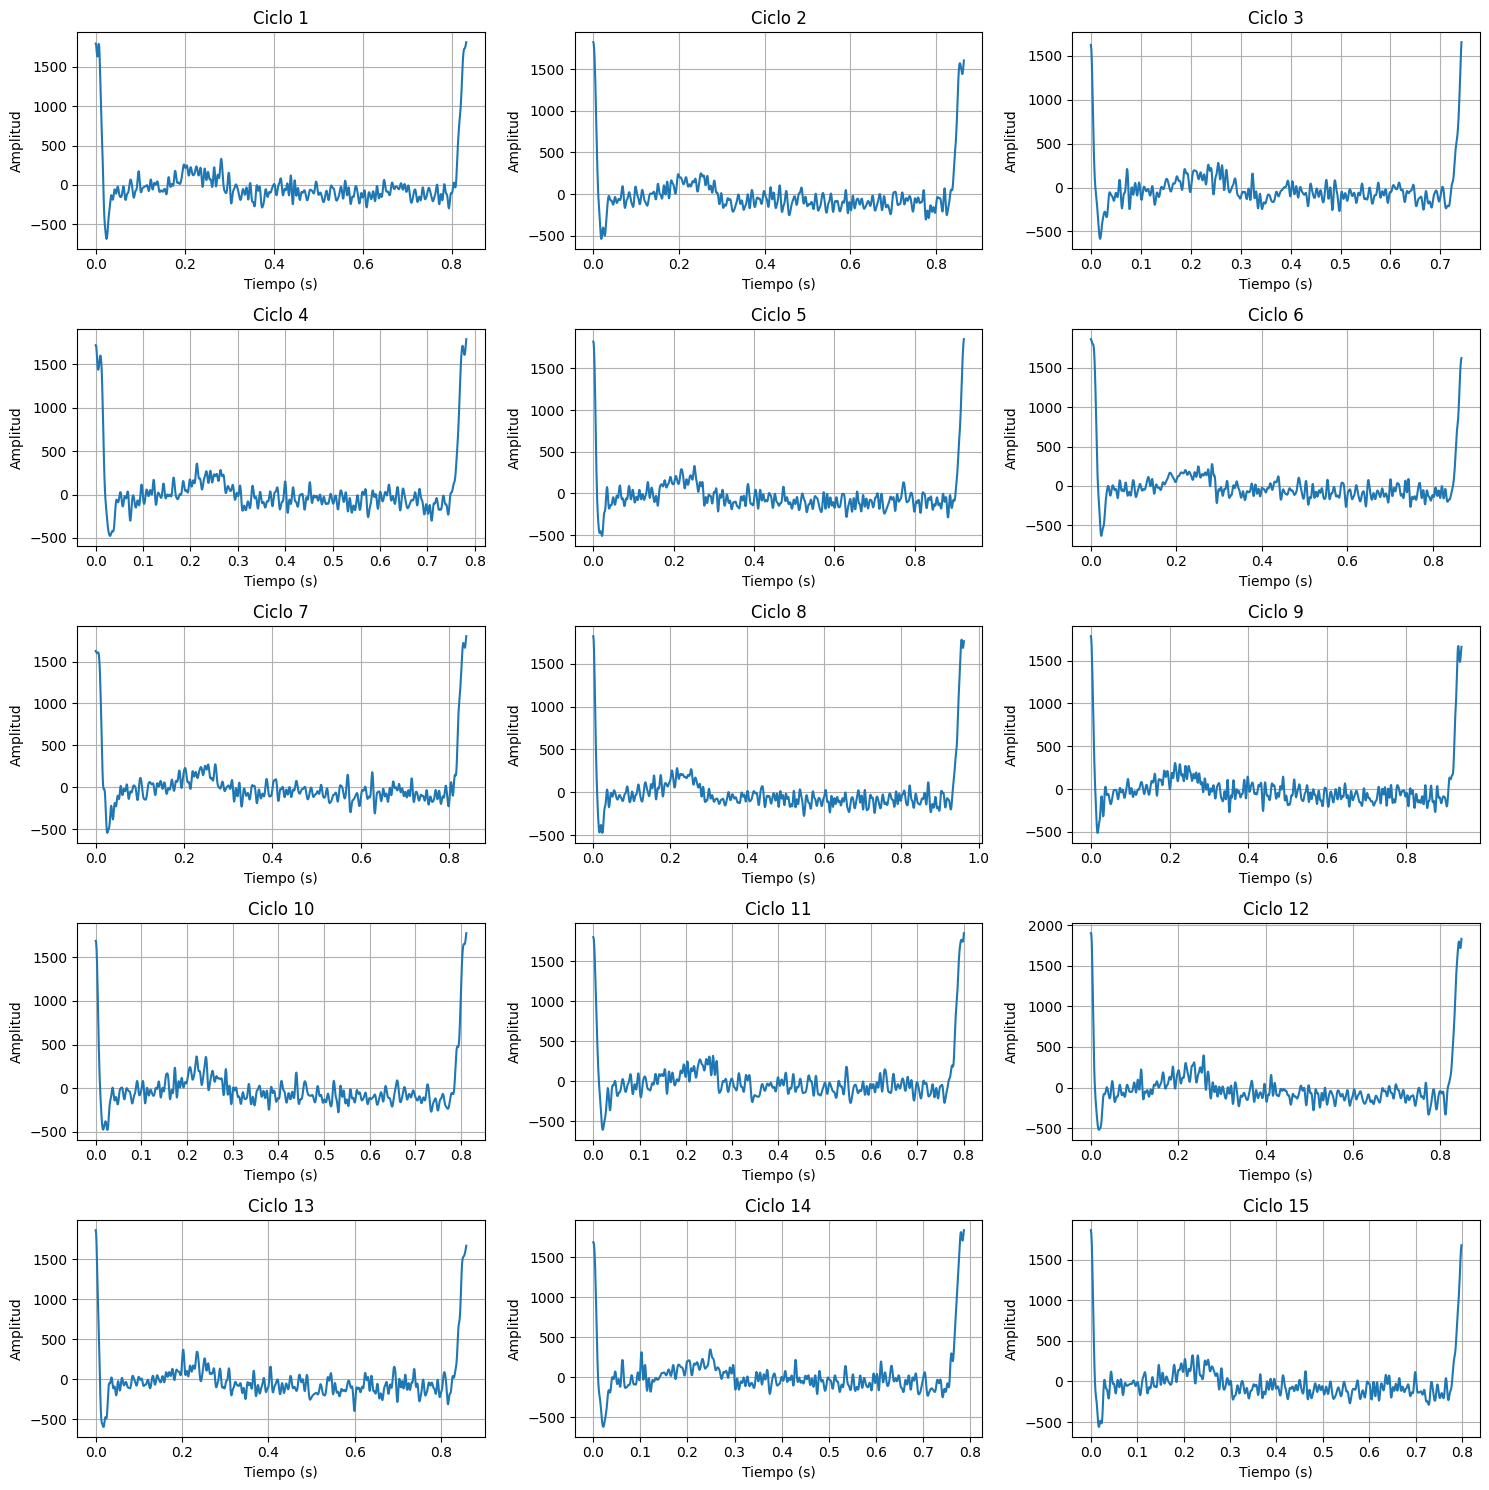

In [14]:
plt.figure(figsize=(15,15))

for i, ciclo in enumerate(ciclos):
    
    t_local = np.arange(len(ciclo)) / Fs
    
    plt.subplot(5,3,i+1)
    
    plt.plot(t_local, ciclo)
    
    plt.title(f"Ciclo {i+1}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.grid()

plt.tight_layout()
plt.show()

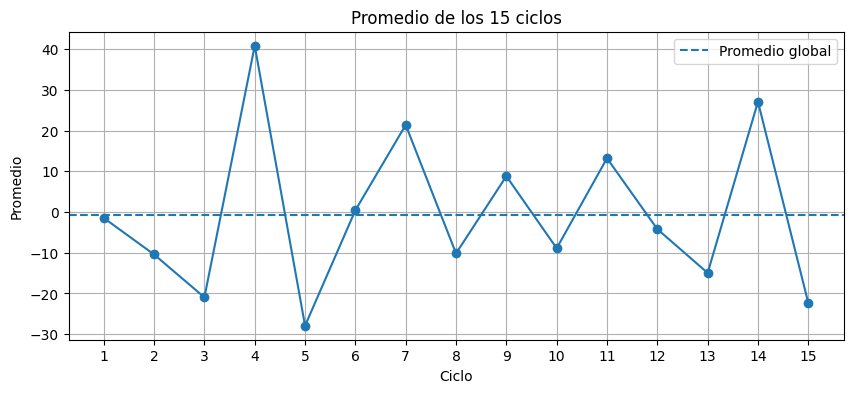

In [15]:
plt.figure(figsize=(10,4))

plt.plot(
    np.arange(1,16),
    promedios,
    marker="o"
)

plt.axhline(
    np.mean(promedios),
    linestyle="--",
    label="Promedio global"
)

plt.xlabel("Ciclo")
plt.ylabel("Promedio")
plt.title("Promedio de los 15 ciclos")
plt.xticks(np.arange(1,16))
plt.grid()
plt.legend()

plt.show()

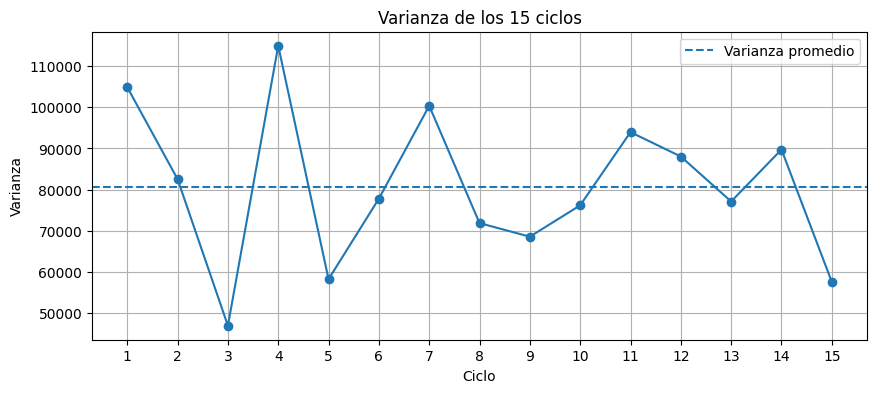

In [16]:
plt.figure(figsize=(10,4))

plt.plot(
    np.arange(1,16),
    varianzas,
    marker="o"
)

plt.axhline(
    np.mean(varianzas),
    linestyle="--",
    label="Varianza promedio"
)

plt.xlabel("Ciclo")
plt.ylabel("Varianza")
plt.title("Varianza de los 15 ciclos")
plt.xticks(np.arange(1,16))
plt.grid()
plt.legend()

plt.show()

De acuerdo a lo que se observa de las medidas estadisticas obtenidas se puede considerar que la señal no es estacionaria ya que estas difieren en grandes rangos en cada ciclo.

In [18]:
ciclo1 = ciclos[0]
ciclo2 = ciclos[1]
shapiro1 = stats.shapiro(ciclo1)
shapiro2 = stats.shapiro(ciclo2)

print("Ciclo 1:")
print(shapiro1)

print("\nCiclo 2:")
print(shapiro2)

levene12 = stats.levene(ciclo1, ciclo2)

print("Levene ciclo 1 vs ciclo 2")
print("Estadístico:", levene12.statistic)
print("p-value:", levene12.pvalue)

Ciclo 1:
ShapiroResult(statistic=0.5502956919467425, pvalue=4.438228165718927e-42)

Ciclo 2:
ShapiroResult(statistic=0.5641397695403821, pvalue=2.975254034041299e-42)
Levene ciclo 1 vs ciclo 2
Estadístico: 0.8442968250331496
p-value: 0.3582981888617296


Considerando la hipótesis nula H0​:los datos presentan distribución normal, si p > 0.05 no se rechaza normalidad, por tanto en ambos ciclos se concluye que no provienen de una distribución normal. Por otro lado la prueba de levene considera la hipótesis nula H0:Las varianzas de los grupos son iguales (homogeneidad de varianza), a partir de los resultados se afirma que hay evidencia de homocedasticidad, sin embargo al no cumplirse el supuesto de normalidad se debe aplicar una prueba no parámetrica.

In [19]:
mann12 = stats.mannwhitneyu(
    ciclo1,
    ciclo2,
    alternative="two-sided"
)

print("Mann-Whitney ciclo 1 vs ciclo 2")
print("U:", mann12.statistic)
print("p-value:", mann12.pvalue)

Mann-Whitney ciclo 1 vs ciclo 2
U: 377790.0
p-value: 0.9271711289913059


H0: Las dos poblaciones son iguales o tienen la misma tendencia central, por tanto al ser el valor p>0.05 se afirma que los ciclos no presentan diferencias significativas.

In [20]:
ciclo3 = ciclos[2]
ciclo4 = ciclos[3]
shapiro3 = stats.shapiro(ciclo3)
shapiro4 = stats.shapiro(ciclo4)

print("Ciclo 3:")
print(shapiro3)

print("\nCiclo 4:")
print(shapiro4)
levene34 = stats.levene(ciclo3, ciclo4)

print("Levene ciclo 3 vs ciclo 4")
print("Estadístico:", levene34.statistic)
print("p-value:", levene34.pvalue)

Ciclo 3:
ShapiroResult(statistic=0.6606662453960939, pvalue=2.5586738564090947e-36)

Ciclo 4:
ShapiroResult(statistic=0.5666946090018149, pvalue=1.6230300122465054e-40)
Levene ciclo 3 vs ciclo 4
Estadístico: 12.306001525334551
p-value: 0.0004643053549308521


In [21]:
mann34 = stats.mannwhitneyu(
    ciclo3,
    ciclo4,
    alternative="two-sided"
)

print("Mann-Whitney ciclo 3 vs ciclo 4")
print("U:", mann34.statistic)
print("p-value:", mann34.pvalue)

Mann-Whitney ciclo 3 vs ciclo 4
U: 270091.0
p-value: 8.421413997601233e-05


Considerando las mismas hipótesis anteriores se concluye que la comparación entre ciclos no cumple normalidad ni homocedasticidad, y que sí existen diferencias significativas entre ambas a partir de la prueba de Mann-Whitney. En consecuencia, los resultados indican que la señal ECG no puede considerarse estrictamente estacionaria durante todo el registro. Sin embargo, puede presentar intervalos localmente estacionarios en los cuales ciclos consecutivos poseen propiedades estadísticas similares. Este comportamiento es esperable en señales fisiológicas, debido a las variaciones naturales en la frecuencia cardíaca, la morfología de los complejos y otros procesos fisiológicos.

In [28]:

from statsmodels.tsa.stattools import adfuller

resultado_original = adfuller(
    ecg_original,
    autolag='AIC',
    result_object=False)

print("SEÑAL ORIGINAL")
print("Estadístico ADF:", resultado_original[0])
print("p-value:", resultado_original[1])
print("Número de retardos usados:", resultado_original[2])
print("Número de observaciones:", resultado_original[3])
print("Valores críticos:", resultado_original[4])
import warnings
from statsmodels.tools.sm_exceptions import SingularMatrixWarning
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore", category=SingularMatrixWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

resultado_filtrado = adfuller(
    ecg_filtrado,
    autolag="AIC",
    result_object=False
)

print("SEÑAL FILTRADA")
print("Estadístico ADF:", resultado_filtrado[0])
print("p-value:", resultado_filtrado[1])
print("Retardos usados:", resultado_filtrado[2])
print("Observaciones:", resultado_filtrado[3])
print("Valores críticos:", resultado_filtrado[4])

SEÑAL ORIGINAL
Estadístico ADF: -16.443181171303156
p-value: 2.4170027215534456e-29
Número de retardos usados: 51
Número de observaciones: 30668
Valores críticos: {'1%': -3.4305632466228713, '5%': -2.8616342493185662, '10%': -2.5668201660230157}
SEÑAL FILTRADA
Estadístico ADF: -29.941484788527937
p-value: 0.0
Retardos usados: 19
Observaciones: 30700
Valores críticos: {'1%': -3.4305630243276717, '5%': -2.861634151073544, '10%': -2.5668201137295887}


La hipotesis H0​ de la prueba de Dickey-Fuller plantea que la señal tiene raíz unitaria, es decir, no es estacionaria, considerando los valores p obtenidos, se rechaza dicha hipótesis. Estos resultados complementan el análisis realizado entre ciclos. Aunque se encontraron diferencias estadísticas entre algunos ciclos cardíacos individuales, la prueba indica que la señal completa no presenta una tendencia estocástica asociada con una raíz unitaria. Por tanto, las variaciones observadas entre ciclos pueden interpretarse como fluctuaciones locales propias de una señal fisiológica, sin que ello implique necesariamente que la serie completa sea no estacionaria.